#Background Removal Using Neural Networks

This notebook explores background estimation and removal in synthetic radio astronomy spectra using deep learning techniques.

The main objective is to train a neural network capable of estimating the smooth background component of a spectrum while ignoring spectral lines and noise.

The workflow includes:

1. Synthetic spectrum generation
2. Signal preprocessing
3. Dataset construction
4. TensorFlow model development
5. Training and evaluation
6. Background subtraction analysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from enum import Enum

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Step 1 — Global Configuration

In this step we configure the global environment of the notebook.

The main objectives are:
- ensuring reproducibility
- configuring plotting settings
- verifying the TensorFlow installation

In [2]:
# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Plot configuration
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## Step 1 Summary

In this step we configured the notebook environment and initialized reproducibility settings.

Random seeds were fixed for both NumPy and TensorFlow in order to ensure stable and repeatable experiments.

Additionally, default plotting settings were configured to improve visualization consistency throughout the notebook.

# Step 2 — Frequency Axis Generation and Visualization

In this step we generate the synthetic frequency axis that will be used throughout the project.

The selected frequency range is centered near the hydrogen line region around 1420 MHz.

After generating the frequency axis, we visualize it in order to verify:
- the correct number of spectral channels
- the selected frequency range
- the uniform spacing of the samples

In [3]:
NUM_CHANNELS = 1024

FREQ_MIN = 1419.0
FREQ_MAX = 1421.0

freq = np.linspace(FREQ_MIN, FREQ_MAX, NUM_CHANNELS)

print("Frequency axis shape:", freq.shape)
print("Minimum frequency:", freq.min(), "MHz")
print("Maximum frequency:", freq.max(), "MHz")

Frequency axis shape: (1024,)
Minimum frequency: 1419.0 MHz
Maximum frequency: 1421.0 MHz


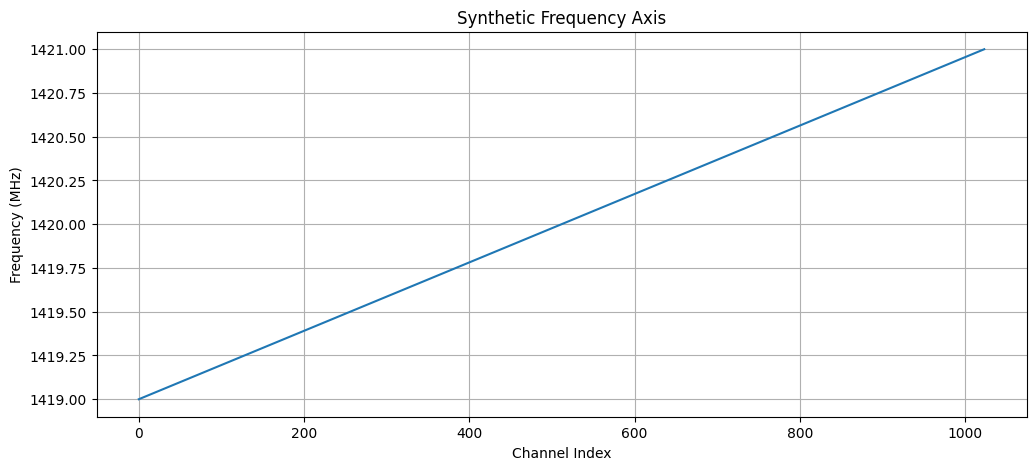

In [4]:
plt.plot(freq)

plt.title("Synthetic Frequency Axis")
plt.xlabel("Channel Index")
plt.ylabel("Frequency (MHz)")

plt.show()

## Step 2 Summary

In this step we generated and visualized the synthetic frequency axis used throughout the entire project.

The generated axis contains 1024 uniformly spaced spectral channels between 1419 MHz and 1421 MHz.

This frequency range is centered near the neutral hydrogen spectral line

# Step 3 — Noise Generation

In this step we generate synthetic Gaussian noise.

Noise is an unavoidable component of real radio astronomy observations and originates from several sources, including:

- receiver electronics,
- thermal fluctuations,
- environmental effects,
- random measurement variations.

For the first version of the pipeline, we assume that noise follows a Gaussian distribution with zero mean.

In [5]:
NOISE_STD = 0.01

noise = np.random.normal(
    loc=0.0,
    scale=NOISE_STD,
    size=NUM_CHANNELS
)

print(f"Noise shape: {noise.shape}")
print(f"Noise mean: {np.mean(noise):.6f}")
print(f"Noise standard deviation: {np.std(noise):.6f}")

Noise shape: (1024,)
Noise mean: 0.000294
Noise standard deviation: 0.009781


## Noise Visualization

Before using the generated noise in the synthetic spectrum pipeline, it is useful to visualize its behavior.

The noise should fluctuate randomly around zero without exhibiting any obvious trend or structure.

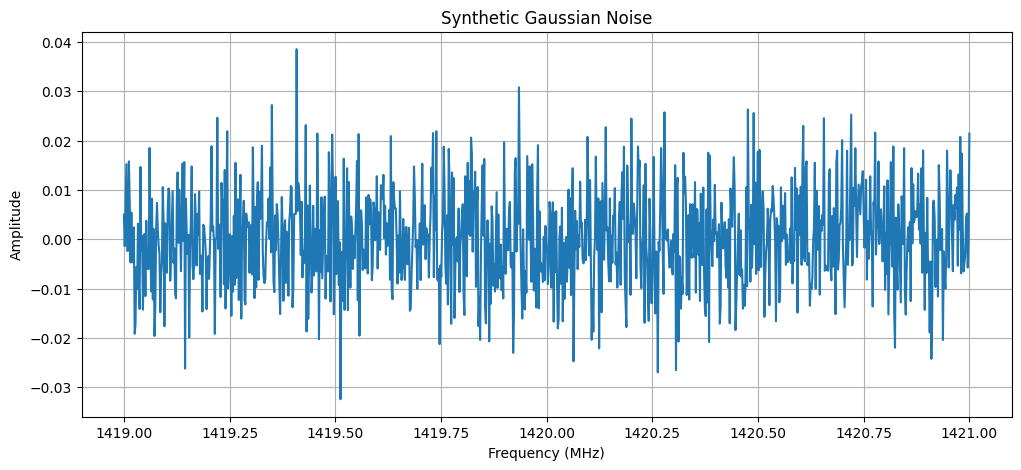

In [6]:
plt.plot(freq, noise)

plt.title("Synthetic Gaussian Noise")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")

plt.show()

## Noise Distribution

A histogram provides a simple way to verify that the generated samples approximately follow a Gaussian distribution.

The distribution should be centered around zero and spread according to the selected standard deviation.

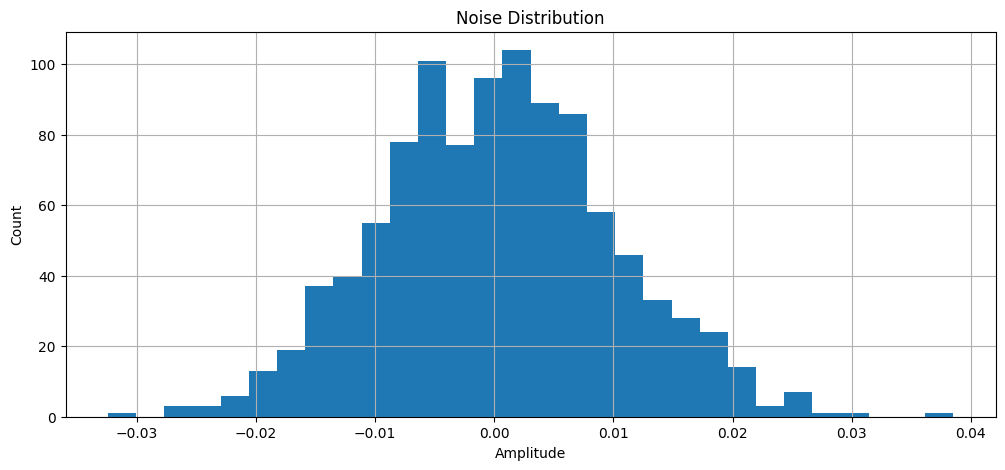

In [7]:
plt.hist(noise, bins=30)

plt.title("Noise Distribution")
plt.xlabel("Amplitude")
plt.ylabel("Count")

plt.show()

## Step 3 Summary

In this step we generated a synthetic Gaussian noise signal with zero mean and a standard deviation of 0.01.

The generated noise contains one value for each spectral channel.

This component will be incorporated into the background generation process and the final synthetic observations.